In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784',version=1, as_frame=False)
mnist.keys()
mnist.data[12]
#dict_keys(['data', 'target', 'feature_names', 'DESCR', 'details', 'categories', 'url'])

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        12,  99,  91, 142, 155, 246, 182, 155, 155, 155, 155, 131,  52,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0, 138, 254, 254, 254, 254, 254, 254, 254, 254, 25

In [9]:
X, y = mnist["data"], mnist["target"]
X.shape
y.shape

(70000,)

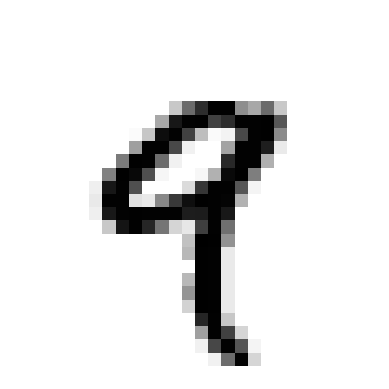

In [10]:
some_digit = X[4]
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [4]:
y[4]

'9'

In [11]:
y=y.astype(np.uint8)

In [6]:
type(y[0])

numpy.uint8

In [12]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
print(X_train)
print(len(X_train))
print(len(X_test))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
56000
14000


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9681428571428572


In [18]:
def convert_to_mnist(image_path):
  #doc anh
  img = cv2.imread(image_path)

  # grayscale
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  # resize 28x28
  img_28 = cv2.resize(gray, (28,28))

  # threshold tach so
  _, img_bin = cv2.threshold(img_28, 120, 255, cv2.THRESH_BINARY)

  # đảm bảo nền trắng (0) và số đen (255)
  # nếu nền đang tối thì đảo
  if np.mean(img_bin) > 127:
      img_bin = 255 - img_bin

  # kiểm tra ảnh
  plt.imshow(img_bin, cmap="gray_r")  # gray_r để hiển thị đúng
  plt.title("MNIST format image")
  plt.axis("off")
  plt.show()

  # flatten thành 784
  img_flat = img_bin.reshape(1,784)
  return img_flat

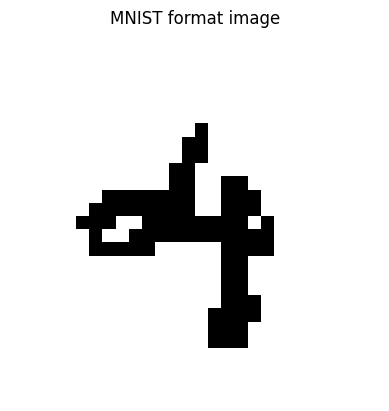

Predicted digit: 4


In [28]:
sample = convert_to_mnist("so4_4.jpg")

prediction = rf_model.predict(sample)

print("Predicted digit:", prediction[0])

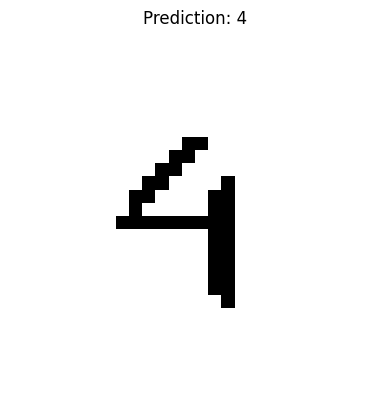

In [26]:
plt.imshow(sample.reshape(28,28), cmap="gray_r")
plt.title(f"Prediction: {prediction[0]}")
plt.axis("off")
plt.show()